In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize

In [4]:
df = pd.read_csv(r"/home/sakthi/Documents/IMDB Dataset.csv")

In [18]:
df.shape

(50000, 3)

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

# Data preprocessing

In [9]:
df['review'].str.lower()
df['review'].astype(str)

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: object

In [10]:
import re

df["review"] = df["review"].apply(
    lambda x: re.sub(r"<.*?>", "", x)
)

In [11]:
df["review"] = df["review"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

In [12]:
df["review"] = df["review"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [16]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["review"].apply(word_tokenize)

In [17]:
df.describe()

,review,sentiment,tokens
count,50000,50000,50000
unique,49580,2,49580
top,Loved todays show It was a variety and not sol...,positive,"[Loved, todays, show, It, was, a, variety, and..."
freq,5,25000,5


# EDA

In [19]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


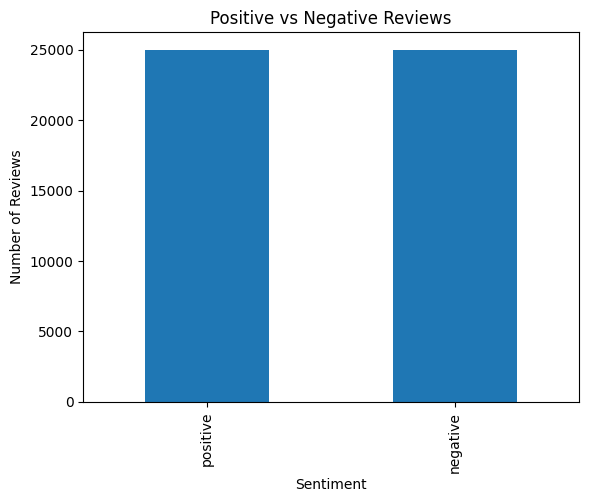

In [20]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
df["review_length"] = df["review"].apply(lambda x: len(x.split()))

In [22]:
print(df[["review", "review_length"]].head())

                                              review  review_length
0  One of the other reviewers has mentioned that ...            300
1  A wonderful little production The filming tech...            156
2  I thought this was a wonderful way to spend ti...            161
3  Basically theres a family where a little boy J...            128
4  Petter Matteis Love in the Time of Money is a ...            222


In [23]:
print(df["review_length"].mean())

225.18978


In [24]:
print("Shortest:", df["review_length"].min())
print("Longest:", df["review_length"].max())

Shortest: 4
Longest: 2441


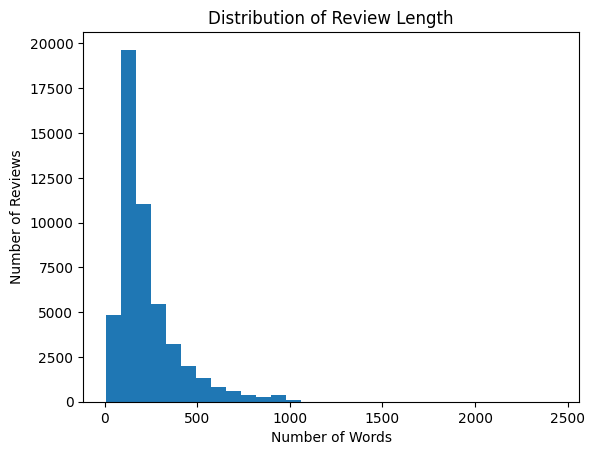

In [25]:
plt.hist(df["review_length"], bins=30)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()